In [2]:
#!pip install laspy

In [3]:
import laspy
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
def load_LAS_from_path(path):
    container = []
    for file_path in os.listdir(path):
        las = laspy.read(path + '\\' + file_path)
        container.append(las)
    return container

In [5]:
train_path = 'D:\\AIDL\\dales_las\\train'
test_path = 'D:\\AIDL\\dales_las\\test'

In [6]:
file_path = 'D:\\AIDL\\dales_las\\train\\5080_54435.las'
las = laspy.read(file_path)

In [7]:
list(las.point_format.dimension_names)

['X',
 'Y',
 'Z',
 'intensity',
 'return_number',
 'number_of_returns',
 'scan_direction_flag',
 'edge_of_flight_line',
 'classification',
 'synthetic',
 'key_point',
 'withheld',
 'scan_angle_rank',
 'user_data',
 'point_source_id',
 'gps_time']

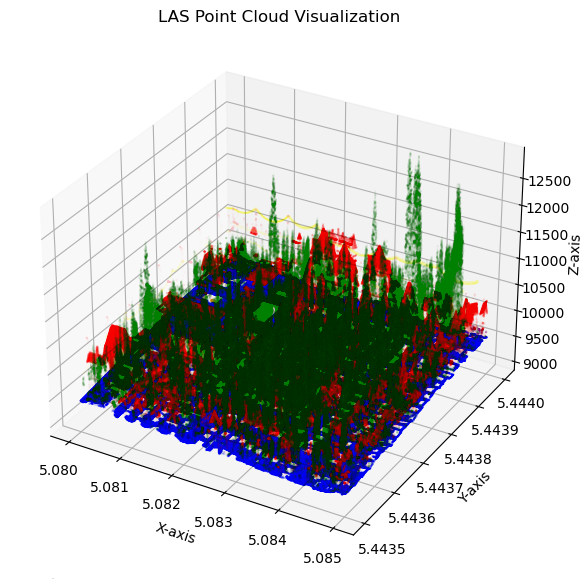

In [9]:
cdict = {1: 'blue', 2: 'green', 3: 'purple', 4:'orange', 5: 'yellow', 6:'white', 7:'pink', 8:'red'}  
fig = plt.figure(figsize=[7,7])
ax = fig.add_subplot(111, projection='3d')

for classification in np.unique(las.classification)[1:]:
    color = cdict.get(classification, 'black')  
    if color == 'green' or 'red':
        ax.scatter(las.X[las.classification == classification],  
               las.Y[las.classification == classification],  
               las.Z[las.classification == classification],  
               s = 0.001, c=color, alpha = 0.2)

    else:
        ax.scatter(las.X[las.classification == classification],  
                las.Y[las.classification == classification],  
                las.Z[las.classification == classification],  
                s = 0.001, c=color)

ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('LAS Point Cloud Visualization')

plt.show()
